# 03 — Embeddings + Clustering para detección de roles

Genera embeddings de mensajes con `nomic-embed-text-v2-moe` (768 dims),  
reduce a 2D con UMAP y agrupa actores con HDBSCAN.  
Contrasta los clusters con los roles inferidos por LLM en el notebook 02.

Produce:
- `data/processed/message_embeddings.npy` — matriz (N, 768)
- `data/processed/actor_embeddings.parquet` — centroide por actor + cluster + rol
- `data/processed/conti_sample_with_embeddings.parquet` — muestra + cluster por mensaje


## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import json
import numpy as np
import pandas as pd
import ollama
import umap
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.auto import tqdm

PROCESSED_DIR   = Path('../data/processed')
SAMPLE_IN       = PROCESSED_DIR / 'conti_sample_classified.parquet'
PROFILES_IN     = PROCESSED_DIR / 'actor_profiles.json'
EMBEDDINGS_NPY  = PROCESSED_DIR / 'message_embeddings.npy'
ACTOR_EMB_OUT   = PROCESSED_DIR / 'actor_embeddings.parquet'
SAMPLE_OUT      = PROCESSED_DIR / 'conti_sample_with_embeddings.parquet'

EMBED_MODEL = 'nomic-embed-text-v2-moe'
EMBED_DIMS  = 768
BATCH_SIZE  = 32  # mensajes por llamada a ollama.embed()

for p in [SAMPLE_IN, PROFILES_IN]:
    assert p.exists(), f'No se encuentra {p} — ejecuta primero el notebook 02'

print('Dependencias OK')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencias OK


## 1. Cargar datos de notebook 02

In [2]:
sample = pd.read_parquet(SAMPLE_IN)
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

print(f'Mensajes en muestra : {len(sample):,}')
print(f'Actores             : {sample.username.nunique()}')
print(f'Perfiles de actores : {len(profiles)}')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

Mensajes en muestra : 1,500
Actores             : 30
Perfiles de actores : 30

Categorías:
category
comms             523
technical         516
unknown           225
operational       141
financial          59
organizational     36


## 2. Generar embeddings de mensajes

`ollama.embed()` acepta listas de textos → procesamos en batches para eficiencia.  
Si ya existe el `.npy`, lo cargamos directamente.

In [3]:
if EMBEDDINGS_NPY.exists():
    embeddings = np.load(EMBEDDINGS_NPY)
    assert len(embeddings) == len(sample), 'Tamaño de embeddings no coincide con la muestra'
    print(f'Embeddings cargados desde caché: {embeddings.shape}')
else:
    texts = sample['message'].str.strip().tolist()
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Generando embeddings'):
        batch = texts[start:start + BATCH_SIZE]
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Embeddings guardados → {EMBEDDINGS_NPY}  {embeddings.shape}')

Generando embeddings: 100%|██████████████████████████████████████████████████████████████████| 47/47 [00:31<00:00,  1.49it/s]

Embeddings guardados → ../data/processed/message_embeddings.npy  (1500, 768)


## 3. Centroides por actor

Cada actor queda representado por la media de los embeddings de sus mensajes.

In [4]:
sample_emb = sample.copy()
sample_emb['emb_idx'] = range(len(sample_emb))

actor_centroids = {}
for actor, group in sample_emb.groupby('username'):
    idxs = group['emb_idx'].tolist()
    actor_centroids[actor] = embeddings[idxs].mean(axis=0)

actor_matrix = np.array([actor_centroids[a] for a in actor_centroids])
actor_names  = list(actor_centroids.keys())

print(f'Centroides calculados: {actor_matrix.shape}  ({len(actor_names)} actores)')

Centroides calculados: (30, 768)  (30 actores)


## 4. UMAP — reducción a 2D

Reducimos tanto los mensajes como los centroides de actores al mismo espacio 2D.

In [5]:
# Ajustamos UMAP sobre los mensajes de la muestra
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

print('Ajustando UMAP sobre mensajes...')
msg_2d = reducer.fit_transform(embeddings)

print('Proyectando centroides de actores...')
actor_2d = reducer.transform(actor_matrix)

print(f'Mensajes en 2D  : {msg_2d.shape}')
print(f'Actores en 2D   : {actor_2d.shape}')

/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ajustando UMAP sobre mensajes...
Proyectando centroides de actores...
Mensajes en 2D  : (1500, 2)
Actores en 2D   : (30, 2)


## 5. HDBSCAN — clustering de actores

Agrupa actores por similitud en el espacio de embeddings (no por volumen de mensajes).  
Cluster `-1` = ruido (actores sin grupo claro).

In [6]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    metric='euclidean'
)
actor_clusters = clusterer.fit_predict(actor_2d)

n_clusters = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise    = (actor_clusters == -1).sum()

print(f'Clusters encontrados : {n_clusters}')
print(f'Actores sin cluster  : {n_noise}')
print()
for cl in sorted(set(actor_clusters)):
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    print(f'  {label:<12}: {members}')

Clusters encontrados : 4
Actores sin cluster  : 1

  ruido       : ['kaktus']
  cluster 0   : ['defender', 'driver', 'hof', 'veron']
  cluster 1   : ['deploy', 'marsel', 'mors']
  cluster 2   : ['baget', 'braun', 'stern']
  cluster 3   : ['angelo', 'bentley', 'bio', 'bloodrush', 'mango', 'mushroom', 'price', 'professor', 'revers', 'strix', 'target', 'tl1', 'tl2', 'tramp', 'ttrr', 'user4', 'user7', 'user8', 'user9']


## 6. Visualizaciones

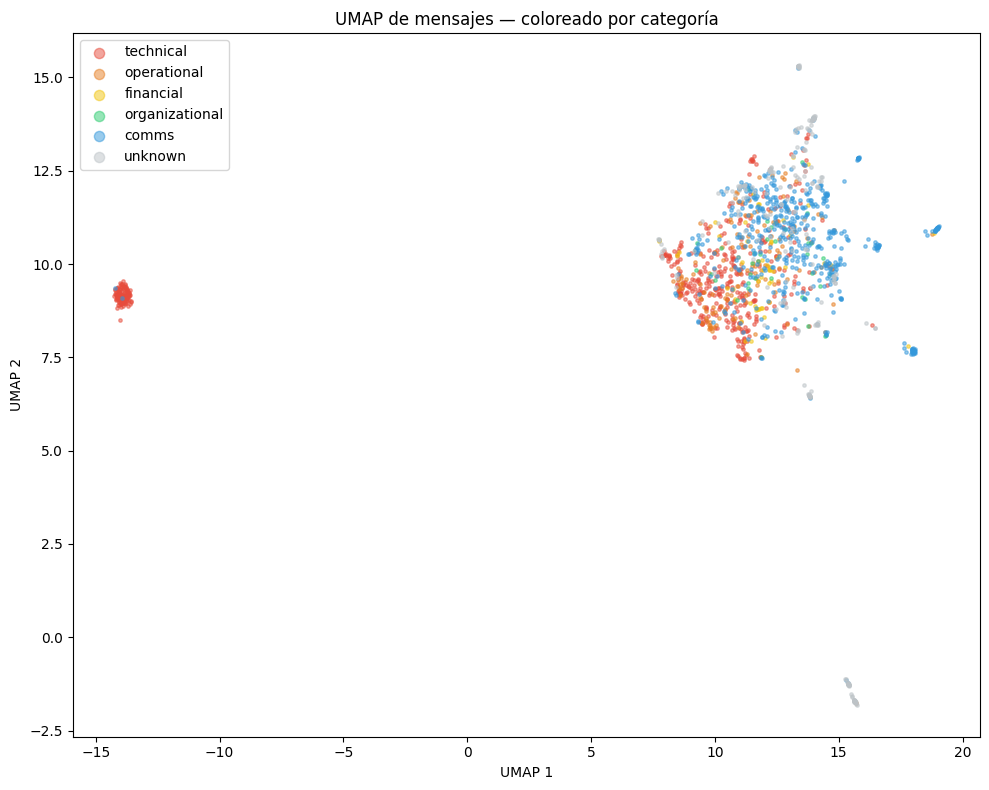

In [7]:
# --- Scatter de mensajes coloreados por categoría ---
cat_color = {
    'technical':      '#e74c3c',
    'operational':    '#e67e22',
    'financial':      '#f1c40f',
    'organizational': '#2ecc71',
    'comms':          '#3498db',
    'unknown':        '#bdc3c7',
}

fig, ax = plt.subplots(figsize=(10, 8))
for cat, color in cat_color.items():
    mask = sample['category'] == cat
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=6, alpha=0.5, label=cat, rasterized=True)

ax.set_title('UMAP de mensajes — coloreado por categoría')
ax.legend(markerscale=3, framealpha=0.8)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

/tmp/ipykernel_22154/4112628696.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


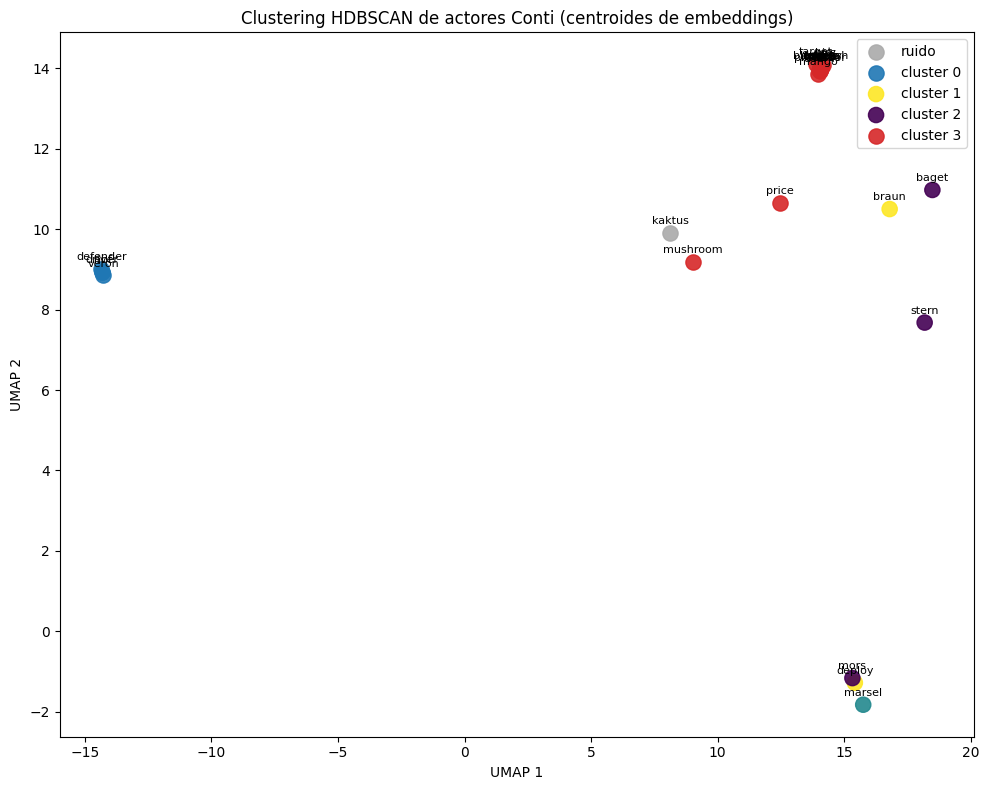

In [8]:
# --- Scatter de actores coloreados por cluster HDBSCAN ---
unique_clusters = sorted(set(actor_clusters))
palette = cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 8))

for cl in unique_clusters:
    mask  = actor_clusters == cl
    color = '#aaaaaa' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=120, alpha=0.9, label=label, zorder=3)

# Etiquetas de actores
for i, name in enumerate(actor_names):
    ax.annotate(name, (actor_2d[i, 0], actor_2d[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('Clustering HDBSCAN de actores Conti (centroides de embeddings)')
ax.legend()
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

In [9]:
# --- Contrastar cluster con rol LLM ---
actor_df = pd.DataFrame({
    'actor':   actor_names,
    'cluster': actor_clusters,
    'umap_x':  actor_2d[:, 0],
    'umap_y':  actor_2d[:, 1],
})
actor_df['llm_role'] = actor_df['actor'].map(
    lambda a: profiles.get(a, {}).get('role', 'unknown')
)
actor_df['llm_confidence'] = actor_df['actor'].map(
    lambda a: profiles.get(a, {}).get('confidence', 'low')
)

print('=== ACTORES: cluster HDBSCAN vs rol LLM ===')
print(actor_df[['actor', 'cluster', 'llm_role', 'llm_confidence']]
      .sort_values(['cluster', 'llm_role'])
      .to_string(index=False))

=== ACTORES: cluster HDBSCAN vs rol LLM ===
    actor  cluster  llm_role llm_confidence
   kaktus       -1 developer           high
      hof        0 developer           high
   driver        0  operator         medium
 defender        0   support           high
    veron        0   support         medium
   deploy        1  operator           high
   marsel        1  operator         medium
     mors        1  operator           high
    baget        2  operator         medium
    braun        2  operator         medium
    stern        2  operator         medium
 mushroom        3 developer           high
professor        3 developer           high
   revers        3 developer           high
     ttrr        3 developer           high
   angelo        3  operator         medium
  bentley        3  operator           high
      bio        3  operator         medium
bloodrush        3  operator         medium
    mango        3  operator           high
    price        3  operator    

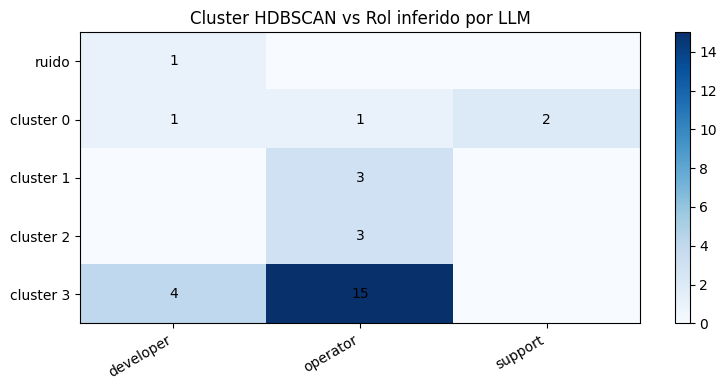

In [10]:
# Heatmap cluster × llm_role
cross = pd.crosstab(actor_df['cluster'], actor_df['llm_role'])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(cross.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels(cross.columns, rotation=30, ha='right')
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels([f'cluster {i}' if i >= 0 else 'ruido' for i in cross.index])
ax.set_title('Cluster HDBSCAN vs Rol inferido por LLM')
plt.colorbar(im, ax=ax)

for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        v = cross.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Actores más similares entre sí (similitud coseno)

Para cada actor, los 3 más cercanos en el espacio de embeddings.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(actor_matrix)
np.fill_diagonal(sim_matrix, -1)  # excluir auto-similitud

print('=== TOP 3 ACTORES MÁS SIMILARES ===')
for i, actor in enumerate(actor_names):
    top3_idx = np.argsort(sim_matrix[i])[::-1][:3]
    top3 = [(actor_names[j], sim_matrix[i, j]) for j in top3_idx]
    pairs = ', '.join(f'{a} ({s:.3f})' for a, s in top3)
    role  = profiles.get(actor, {}).get('role', '?')
    print(f'  {actor:<15} [{role:<15}] → {pairs}')

=== TOP 3 ACTORES MÁS SIMILARES ===
  angelo          [operator       ] → tl1 (0.879), bio (0.877), revers (0.875)
  baget           [operator       ] → braun (0.901), mushroom (0.835), stern (0.832)
  bentley         [operator       ] → mors (0.897), user4 (0.879), deploy (0.875)
  bio             [operator       ] → tramp (0.926), target (0.908), tl1 (0.904)
  bloodrush       [operator       ] → target (0.907), revers (0.906), stern (0.898)
  braun           [operator       ] → baget (0.901), stern (0.894), mango (0.870)
  defender        [support        ] → veron (0.991), driver (0.987), hof (0.937)
  deploy          [operator       ] → marsel (0.907), mors (0.878), bentley (0.875)
  driver          [operator       ] → veron (0.990), defender (0.987), hof (0.914)
  hof             [developer      ] → defender (0.937), veron (0.936), driver (0.914)
  kaktus          [developer      ] → mushroom (0.864), user7 (0.862), bentley (0.853)
  mango           [operator       ] → professor (0

## 8. Guardar

In [12]:
# Añadir cluster y coordenadas UMAP a la muestra de mensajes
actor_to_cluster = dict(zip(actor_names, actor_clusters))
sample_out = sample.copy()
sample_out['cluster']  = sample_out['username'].map(actor_to_cluster)
sample_out['umap_x']   = msg_2d[:, 0]
sample_out['umap_y']   = msg_2d[:, 1]
sample_out.to_parquet(SAMPLE_OUT, index=False)

# Guardar actor_embeddings
actor_df.to_parquet(ACTOR_EMB_OUT, index=False)

print(f'Muestra con embeddings → {SAMPLE_OUT}')
print(f'Actores embeddings     → {ACTOR_EMB_OUT}')
print(f'Embeddings brutos      → {EMBEDDINGS_NPY}  ({EMBEDDINGS_NPY.stat().st_size/1024:.0f} KB)')

print('\n=== RESUMEN FINAL ===')
print(f'  Embeddings generados : {len(embeddings):,} mensajes × {EMBED_DIMS} dims')
print(f'  Actores agrupados    : {len(actor_names)}')
print(f'  Clusters HDBSCAN     : {n_clusters}  (+ {n_noise} en ruido)')

Muestra con embeddings → ../data/processed/conti_sample_with_embeddings.parquet
Actores embeddings     → ../data/processed/actor_embeddings.parquet
Embeddings brutos      → ../data/processed/message_embeddings.npy  (4500 KB)

=== RESUMEN FINAL ===
  Embeddings generados : 1,500 mensajes × 768 dims
  Actores agrupados    : 30
  Clusters HDBSCAN     : 4  (+ 1 en ruido)
